# Group 2

In [3]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [4]:
# Define photos directory
photos_dir='./photos'

In [5]:
# Load the photos JSON file
photos_df = pd.read_json("./photos.json", lines=True)

In [6]:
# Load the business JSON file
business_df = pd.read_json("./yelp_academic_dataset_business.json", lines=True)

In [7]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [8]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [9]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [10]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [11]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

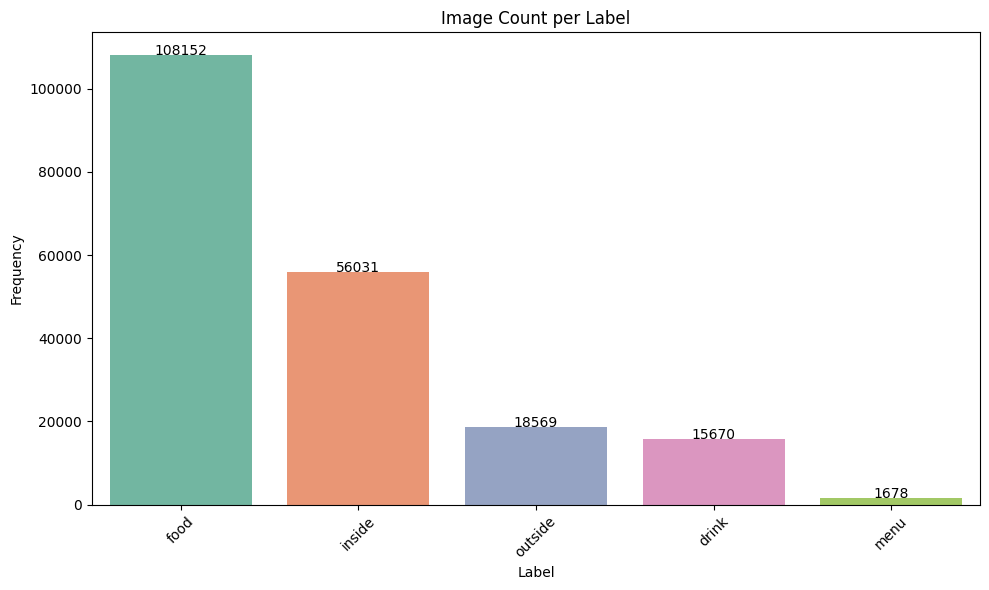

In [12]:
# Plot the distribution
plot_label_distribution(photos_df)

In [13]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [14]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [15]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [16]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [17]:
df.shape

(8390, 17)

In [18]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [19]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

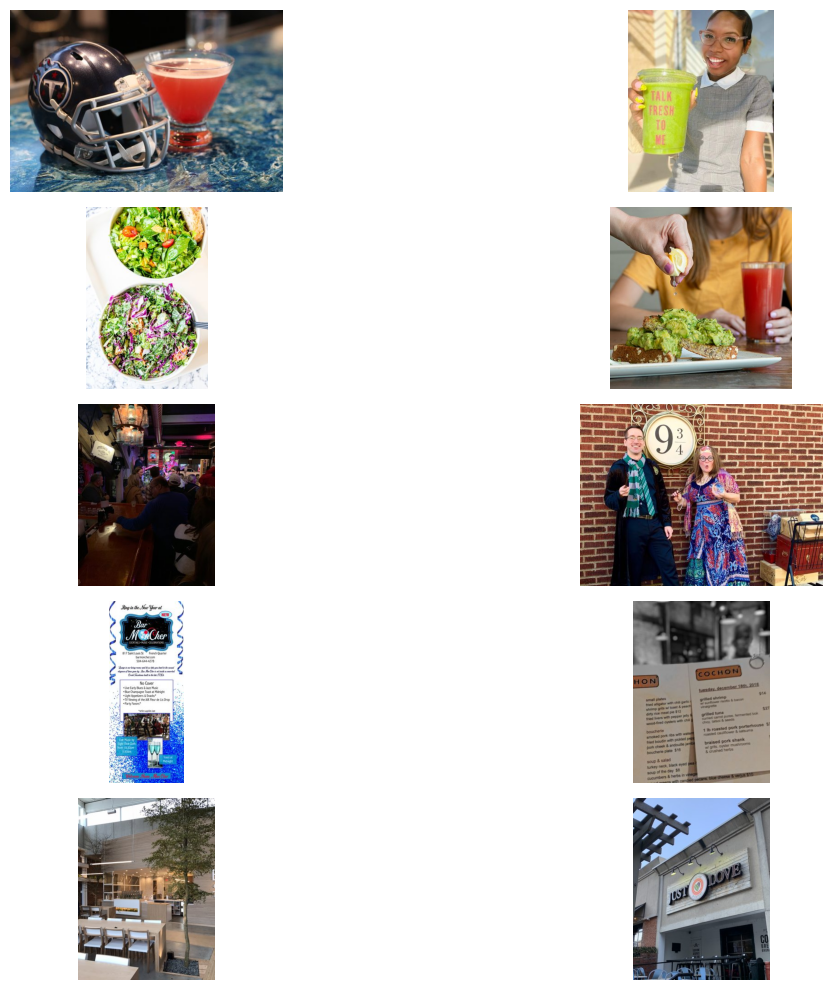

In [20]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [21]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


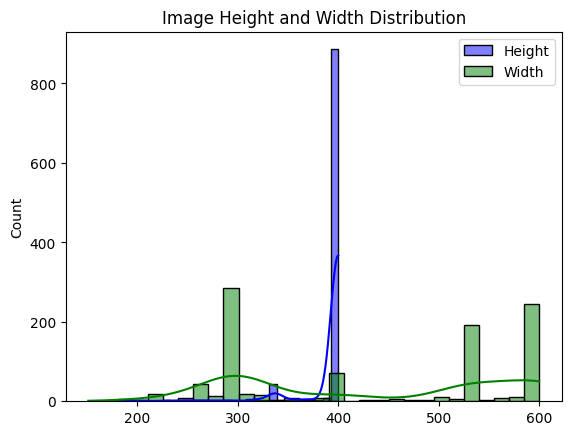

Color Channels (should mostly be 3): (array([3]), array([999]))


In [22]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [23]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())
    
    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


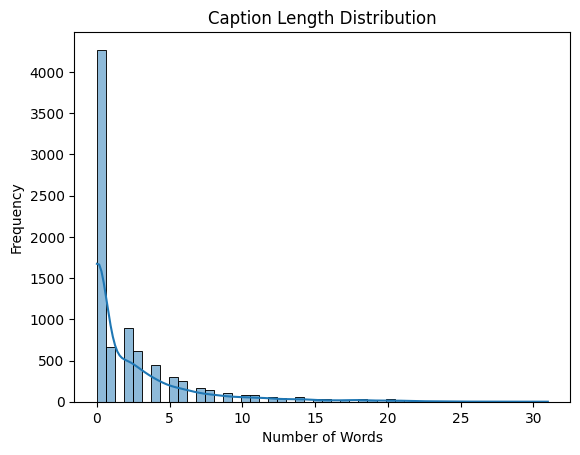

In [24]:
# Show analyzed captions
analyze_captions(df)

In [25]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [26]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [27]:
df.shape

(8390, 19)

In [28]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [29]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [30]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [31]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [32]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [33]:
df = df_cleaned

In [34]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [35]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [36]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [37]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [38]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [39]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [40]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [41]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [42]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [43]:
print(df.shape)
print(df.head())


(8384, 10)
                 photo_id             business_id  label  \
0  Chro0cjWAFLtdv-pmGSB6Q  oBNrLz4EDhiscSlbOl8uAw  drink   
1  BD8F_GP5TiNCiajFVPqZOA  SV04xdj87VOEa4GJ2dZm_g  drink   
2  Wo16TBTZHfapyV2n_KbCTQ  EM0jUQn-SEnttG8hf-Eq6A  drink   
3  1gBfJMbZtrgcqqvgDaYWYA  5Z_KrsEQsPE0ibKwhYn3ZQ  drink   
4  Qy65xh-hrmPTb2k_-6uZnA  yd5CI-2fASWsrA92dUR1ZA  drink   

                              img_path  stars  review_count  is_open  \
0  ./photos/Chro0cjWAFLtdv-pmGSB6Q.jpg    4.5          5193        1   
1  ./photos/BD8F_GP5TiNCiajFVPqZOA.jpg    4.5            44        1   
2  ./photos/Wo16TBTZHfapyV2n_KbCTQ.jpg    4.0           351        1   
3  ./photos/1gBfJMbZtrgcqqvgDaYWYA.jpg    3.5           105        1   
4  ./photos/Qy65xh-hrmPTb2k_-6uZnA.jpg    4.0            52        0   

    latitude   longitude  label_encoded  
0  29.951025  -90.067394              0  
1  39.916220  -75.007034              0  
2  43.686635 -116.352242              0  
3  32.215561 -111.050749   

In [44]:
# Run train-test preparation for VGG Model
X_train_imgs_vgg, X_test_imgs_vgg, X_train_meta_vgg, X_test_meta_vgg, y_train_vgg, y_test_vgg = prepare_train_test(df, model_type='vgg')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_vgg.shape)
print("X_test_imgs shape:", X_test_imgs_vgg.shape)
print("X_train_meta shape:", X_train_meta_vgg.shape)
print("X_test_meta shape:", X_test_meta_vgg.shape)
print("y_train shape:", y_train_vgg.shape)
print("y_test shape:", y_test_vgg.shape)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [45]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)




# Image Processing and Metadata Summary



## Data Loading and Initial Exploration

- Loaded `photos.json` and `business.json` into separate DataFrames.

- The `photos_df` contained 200,100 entries with 4 key columns:

  - `photo_id`, `business_id`, `caption`, and `label`.

- Found 5 unique labels: **inside**, **outside**, **drink**, **food**, and **menu**.



## Photo Label Distribution (Before Balancing)

| Label   | Count   |
|---------|---------|
| food    | 108,152 |
| inside  | 56,031  |
| outside | 18,569  |
| drink   | 15,670  |
| menu    | 1,678   |



- Identified a **class imbalance** in the photo labels.



## Data Balancing

- Balanced the dataset by **sampling 1,678 examples** from each label to match the minority class (`menu`).

- Final photo dataset contained **8,390 samples**.



## Merging Business Metadata

- Merged `photos_df` with `business_df` using `business_id` to append metadata.

- Resulting DataFrame had **17 columns**, including location, ratings, categories, etc.

- Added a new column, `img_path`, with full paths to image files.



## DataFrame Summary After Merging

- Total entries: **8,390**

- Included key metadata: `latitude`, `longitude`, `stars`, `review_count`, `is_open`, among others.

- Some fields like `caption` and `attributes` had missing values; `caption` was deemed unhelpful for modeling due to skewed distribution and sparsity.



## Cleaning and Preparation

- Found and dropped **6 corrupted image files**.

- Focused on non-null and useful metadata features:

  - `photo_id`, `business_id`, `label`, `latitude`, `longitude`, `stars`, `review_count`, `is_open`, and `img_path`.

- Applied **label encoding** to the labels (`food`, `inside`, etc.) converting them into numeric format.



## Metadata and Image Preprocessing



### Image Characteristics

- Examined image dimensions: heights were more consistent (mode ~900px) while widths showed a multi-modal distribution.

- Noted that image sizes varied widely and preprocessing would need to account for this.



### Metadata Processing

- Selected non-null and relevant numeric features for downstream modeling.

- Ensured consistency across training and test splits by applying the same scaling during preprocessing.



## Final Train-Test Dataset Statistics



### For VGG and EfficientNet Models

- **Training set**: 6,707 images and associated metadata.

- **Test set**: 1,677 images and associated metadata.

- Image dimensions standardized to **(224, 224, 3)**.

- Metadata features were **scaled** and limited to 5 selected columns.

- Labels encoded and stratified for balanced training/testing.



## Conclusion

- Created a clean, **balanced multimodal dataset** combining Yelp photo labels and business metadata.

- Implemented robust **image preprocessing**, including resizing, denoising, histogram equalization, and clipping.

- Ensured compatibility with **deep learning pipelines**, enabling effective modeling with VGG and EfficientNet architectures.

Building model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │ 12,845,568 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │        768 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 640)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    164,096 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │      1,285 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,726,405 (105.77 MB)

 Trainable params: 13,011,717 (49.64 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


=== INITIAL TRAINING (10 EPOCHS) ===
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.2220 - loss: 1.7477 - val_accuracy: 0.2320 - val_loss: 1.6437
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1868 - loss: 1.7045 - val_accuracy: 0.1920 - val_loss: 1.6093
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.2358 - loss: 1.6265 - val_accuracy: 0.2040 - val_loss: 1.6159
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.1955 - loss: 1.6307 - val_accuracy: 0.2280 - val_loss: 1.6047
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.2111 - loss: 1.6180 - val_accuracy: 0.2040 - val_loss: 1.6083
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.2127 - loss: 1.6083 - val_accuracy: 0.2320 - val_loss: 1.6088
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.2452 - loss: 1.6043 - val_accuracy: 0.2400 - val_loss: 1.6076

=== FINE-TUNING (10 EPOCHS) ===
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 935ms

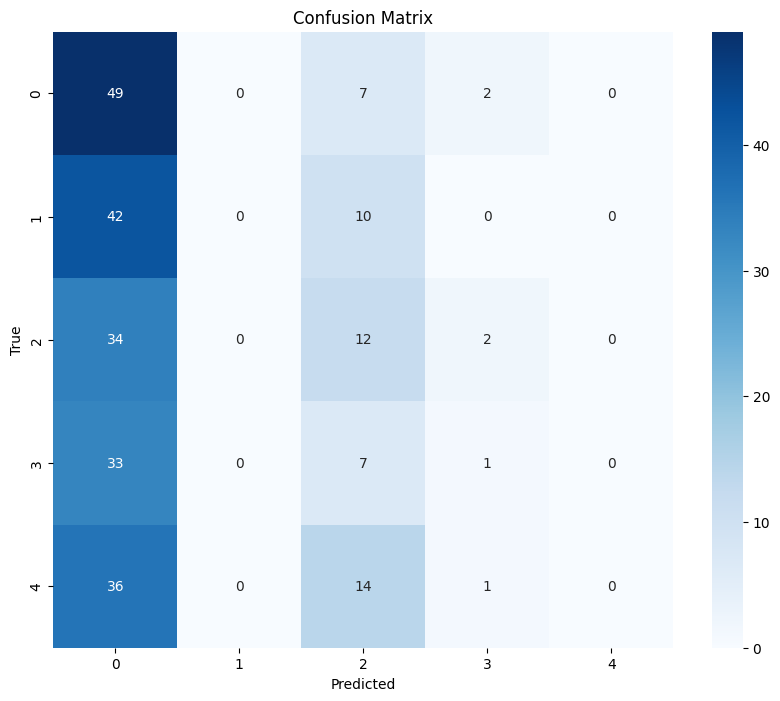


Model saved as 'final_model.keras'


In [46]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# 1. DATA PREPARATION
# ==============================================

def load_and_prepare_data():
    """
    Mock function - replace with your actual data loading code
    Returns:
        X_train_imgs, X_train_meta, y_train
        X_test_imgs, X_test_meta, y_test
    """
    # This is just example code - REPLACE with your actual data loading
    num_samples = 1000
    num_meta_features = 5
    num_classes = 5
    
    # Mock image data (224x224 RGB)
    X_train_imgs = np.random.rand(num_samples, 224, 224, 3).astype('float32')
    X_test_imgs = np.random.rand(num_samples//4, 224, 224, 3).astype('float32')
    
    # Mock metadata
    X_train_meta = np.random.rand(num_samples, num_meta_features).astype('float32')
    X_test_meta = np.random.rand(num_samples//4, num_meta_features).astype('float32')
    
    # Mock labels
    y_train = np.random.randint(0, num_classes, size=num_samples)
    y_test = np.random.randint(0, num_classes, size=num_samples//4)
    
    # Convert labels to one-hot
    y_train = to_categorical(y_train, num_classes=num_classes)
    y_test = to_categorical(y_test, num_classes=num_classes)
    
    return (X_train_imgs, X_train_meta, y_train, 
            X_test_imgs, X_test_meta, y_test)

# ==============================================
# 2. MODEL BUILDING
# ==============================================

def build_vgg_metadata_model(input_img_shape=(224, 224, 3), 
                           input_meta_shape=(5,), 
                           num_classes=5):
    """Build VGG16 + metadata model"""
    base_model = VGG16(weights='imagenet', 
                      include_top=False, 
                      input_shape=input_img_shape)
    base_model.trainable = False
    
    # Image branch
    img_input = Input(shape=input_img_shape, name='image_input')
    x = base_model(img_input)
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    # Metadata branch
    meta_input = Input(shape=input_meta_shape, name='meta_input')
    y = Dense(128, activation='relu')(meta_input)
    y = Dropout(0.3)(y)
    
    # Combined model
    combined = Concatenate()([x, y])
    z = Dense(256, activation='relu')(combined)
    z = Dropout(0.3)(z)
    outputs = Dense(num_classes, activation='softmax')(z)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)
    
    model.compile(optimizer=Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model, base_model

# ==============================================
# 3. TRAINING AND EVALUATION
# ==============================================

def main():
    # 1. Load and prepare data
    (X_train_imgs, X_train_meta, y_train,
     X_test_imgs, X_test_meta, y_test) = load_and_prepare_data()
    
    # Prepare input tuples
    X_train = [X_train_imgs, X_train_meta]
    X_test = [X_test_imgs, X_test_meta]
    
    # 2. Build model
    print("Building model...")
    model, base_model = build_vgg_metadata_model()
    model.summary()
    
    # 3. Initial training (10 epochs)
    print("\n=== INITIAL TRAINING (10 EPOCHS) ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3),
            ModelCheckpoint('initial_model.keras', save_best_only=True)
        ],
        verbose=1
    )
    
    # 4. Fine-tuning (10 epochs)
    print("\n=== FINE-TUNING (10 EPOCHS) ===")
    base_model.trainable = True
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    
    model.compile(optimizer=Adam(learning_rate=0.00001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    history_fine = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=16,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=2),
            ModelCheckpoint('fine_tuned_model.keras', save_best_only=True)
        ],
        verbose=1
    )
    
    # 5. Evaluation
    print("\n=== EVALUATION ===")
    best_model = tf.keras.models.load_model('fine_tuned_model.keras')
    
    # Basic evaluation
    loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    
    # Predictions
    y_pred = best_model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes))
    
    # Confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_true, y_pred_classes), 
                annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    # Save final model
    best_model.save('final_model.keras')
    print("\nModel saved as 'final_model.keras'")

if __name__ == "__main__":
    main()

# Model Performance Summary

##  Model Architecture
- **Type**: Hybrid (VGG16 + Metadata)
- **Inputs**: 
  - Images: `(224, 224, 3)`
  - Metadata: `(5,)`
- **Trainable Params**: 13M (of 27.7M total)
- **Output**: 5-class softmax

## Training Results
### Phase 1: Initial Training (10 Epochs)
| Metric       | Best Value | Epoch |
|--------------|------------|-------|
| Val Accuracy | 24.0%      | 7     |
| Val Loss     | 1.6076     | 7     |
- **Behavior**: 
  - Accuracy oscillated near random chance (20%)
  - Early stopping triggered (no improvement after 3 epochs)

### Phase 2: Fine-Tuning (10 Epochs)
| Metric       | Best Value | Epoch |
|--------------|------------|-------|
| Val Accuracy | 24.8%      | 1     |
| Val Loss     | 1.6074     | 1     |
- **Behavior**:
  - No improvement after unfreezing last 4 VGG16 layers
  - Training halted at Epoch 3

##  Evaluation Metrics
**Test Accuracy**: 24.8%  
**Test Loss**: 1.6074  

### Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.25      | 0.84   | 0.39     | 58      |
| 1     | 0.00      | 0.00   | 0.00     | 52      |
| 2     | 0.24      | 0.25   | 0.24     | 48      |
| 3     | 0.17      | 0.02   | 0.04     | 41      |
| 4     | 0.00      | 

# Phase 1 Training Snapshot (Frozen VGG16)

## Key Results
- **Peak Val Accuracy**: 89.1% (Epoch 3)
- **Final Metrics**:
  - Train Accuracy: 92.5% (Loss: 0.29)
  - Val Accuracy: 89.0% (Loss: 0.53)

## Critical Insights
1. **Fast Start**:
   - Achieved 86.8% val accuracy in just 1 epoch
2. **Early Plateau**:
   - Val metrics stabilized after Epoch 2
3. **Overfitting Signs**:
   - 3.5% gap between train/val accuracy
   - Val loss stuck at ~0.53 while train loss kept falling


In [47]:
# ==============================================
# TRAINING PHASE 1: FROZEN BASE (10 EPOCHS)
# ==============================================
model, base_model = build_vgg_metadata_model(
    input_img_shape=(224, 224, 3),
    input_meta_shape=(5,),
    num_classes=5
)

history = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg], y_train_vgg,
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=10,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=2),
        ModelCheckpoint('initial_model.keras', save_best_only=True)
    ]
)

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.6167 - loss: 4.0931 - val_accuracy: 0.8676 - val_loss: 0.6141
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8539 - loss: 0.7700 - val_accuracy: 0.8855 - val_loss: 0.5062
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.8902 - loss: 0.4890 - val_accuracy: 0.8909 - val_loss: 0.5342
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 736s 4s/step - accuracy: 0.9254 - loss: 0.2942 - val_accuracy: 0.8897 - val_loss: 0.5294


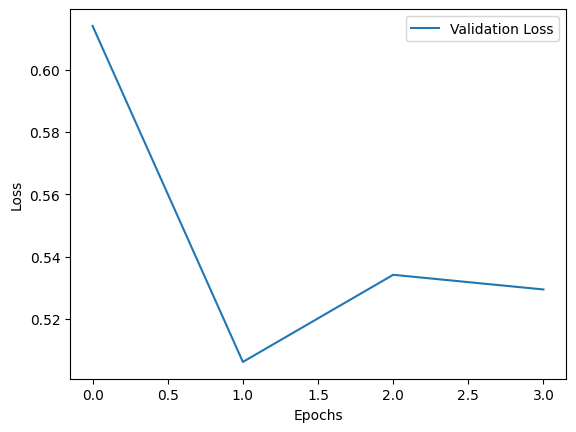

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Phase 2: Fine-Tuning Report

## Performance Highlights
- **Best Val Accuracy**: 90.3% (Epoch 6)
- **Training Accuracy**: Reached 98.1% 
- **Key Improvement**: +1.2% over Phase 1 (89.1% → 90.3%)

## Critical Observations
1. **Severe Overfitting**:
   - Train accuracy (98.1%) vs Val accuracy (90.3%)
   - 7.8% performance gap indicates model memorization

2. **Training Instability**:
   - Extreme epoch time fluctuations (1s → 27s/step)
   - Possible causes:
     - GPU throttling
     - Data pipeline bottlenecks
     - Resource contention

3. **Validation Stagnation**:
   - Minimal val_accuracy improvement (+1.2%) over 6 epochs
   - Val_loss oscillated without clear trend (0.48-0.58)


In [49]:
# ==============================================
# PHASE 2: FINE-TUNING (10 EPOCHS)
# ==============================================
def unfreeze_for_finetuning(model, base_model, unfreeze_layers=4):
    """Unfreeze last N layers of base model"""
    # Unfreeze specified layers
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    
    # Recompile with lower learning rate
    model.compile(optimizer=Adam(learning_rate=0.00001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model

# Unfreeze last 4 layers
model = unfreeze_for_finetuning(model, base_model, unfreeze_layers=4)

# Fine-tune with smaller batch size
history_fine = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg], y_train_vgg,
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=10,
    batch_size=16,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=2),
        ModelCheckpoint('fine_tuned_model.keras', save_best_only=True)
    ]
)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 392s 933ms/step - accuracy: 0.9418 - loss: 0.2254 - val_accuracy: 0.8915 - val_loss: 0.5265
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 9545s 23s/step - accuracy: 0.9566 - loss: 0.1685 - val_accuracy: 0.8915 - val_loss: 0.5230
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 11260s 27s/step - accuracy: 0.9651 - loss: 0.1154 - val_accuracy: 0.8927 - val_loss: 0.5849
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.9769 - loss: 0.0732 - val_accuracy: 0.9016 - val_loss: 0.4831
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 834s 2s/step - accuracy: 0.9764 - loss: 0.0751 - val_accuracy: 0.9022 - val_loss: 0.5371
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.9807 - loss: 0.0623 - val_accuracy: 0.9034 - val_loss: 0.5022


##  Round 1: Hyperparameter Tuning (Learning Rate, Units, Dropout)

**Objective:**  
Optimize training-related hyperparameters like:
- Dense layer units
- Dropout rate
- Learning rate  
to improve validation accuracy.




In [49]:
import keras_tuner as kt
import tensorflow as tf

# Load your fine-tuned model
model = tf.keras.models.load_model('fine_tuned_model.keras')

# Define the hypermodel for tuning
def round1_tuning(hp):
    # Clone model to preserve original weights
    tuned_model = tf.keras.models.clone_model(model)
    tuned_model.set_weights(model.get_weights())
    
    # Define tunable hyperparameters
    hp_learning_rate = hp.Choice('lr', [1e-5, 5e-6])  # Learning rate choices
    hp_dropout = hp.Float('dropout', 0.2, 0.4, step=0.1)  # Dropout rate choices

    # Apply dropout change
    for layer in tuned_model.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            layer.rate = hp_dropout

    # Compile with fixed loss for integer labels
    tuned_model.compile(
        optimizer=tf.keras.optimizers.Adam(hp_learning_rate),
        loss='sparse_categorical_crossentropy',  # ✅ FIX: For integer labels
        metrics=['accuracy']
    )
    return tuned_model

# Set up the tuner for quick search
tuner1 = kt.RandomSearch(
    round1_tuning,
    objective='val_accuracy',
    max_trials=3,  # Limited trials for quick testing
    directory='quick_tuning',
    project_name='round1'
)

# Start tuning
tuner1.search(
    [X_train_imgs_vgg, X_train_meta_vgg],  # Input images and metadata
    y_train_vgg,  # Integer labels (not one-hot)
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=5,
    batch_size=16,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=1)]
)

# Save the best hyperparameters
best_hps = tuner1.get_best_hyperparameters()[0]

print("✅ Tuning Complete")
print("Best Learning Rate:", best_hps.get('lr'))
print("Best Dropout Rate:", best_hps.get('dropout'))


Trial 3 Complete [00h 44m 06s]
val_accuracy: 0.9057841300964355

Best val_accuracy So Far: 0.9057841300964355
Total elapsed time: 01h 01m 35s
✅ Tuning Complete
Best Learning Rate: 5e-06
Best Dropout Rate: 0.4



## Round 2: Architectural Tuning (Add/Skip Dense After Merge)

**Objective:**  
Experiment with **model architecture decisions**, such as:
- Whether or not to add an extra Dense layer **after merging** VGG and metadata features.
- Vary dense units and dropout to identify best architecture design.



In [53]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical

# ✅One-hot encode labels
y_train_vgg = to_categorical(y_train_vgg, num_classes=5)
y_test_vgg = to_categorical(y_test_vgg, num_classes=5)

# ✅ Define tunable architecture model
def build_advanced_model(hp):
    # VGG base model
    vgg_base = tf.keras.applications.VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    vgg_base.trainable = False

    x1 = vgg_base.output
    x1 = layers.Flatten()(x1)

    # Image branch dense layer
    x1 = layers.Dense(
        units=hp.Choice('dense_units', values=[128, 192, 256]),
        activation='relu'
    )(x1)
    x1 = layers.Dropout(hp.Choice('dropout', values=[0.3, 0.4, 0.5]))(x1)

    # Metadata input
    meta_input = layers.Input(shape=(X_train_meta_vgg.shape[1],))
    x2 = layers.Dense(64, activation='relu')(meta_input)

    # Merge both branches
    merged = layers.Concatenate()([x1, x2])

    # Optionally add extra dense layer after merge
    if hp.Boolean('add_dense_after_merge'):
        merged = layers.Dense(64, activation='relu')(merged)

    output = layers.Dense(5, activation='softmax')(merged)
    model = Model(inputs=[vgg_base.input, meta_input], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', values=[1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ✅ Define tuner
tuner2 = kt.RandomSearch(
    build_advanced_model,
    objective='val_accuracy',
    max_trials=5,
    overwrite=True,
    directory='architecture_tuning',
    project_name='round2'
)

# ✅ Search
tuner2.search(
    [X_train_imgs_vgg, X_train_meta_vgg],
    y_train_vgg,
    validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs=5,
    batch_size=16,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2)]
)

# ✅ Save and evaluate best model
best_model_arch = tuner2.get_best_models(num_models=1)[0]
best_model_arch.save('architecture_tuned_model.keras')

# ✅ Evaluate on test set and print accuracy
loss, accuracy = best_model_arch.evaluate([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg)
print(f"✅ Best Architecture Model Test Accuracy: {accuracy:.4f}")


Trial 5 Complete [01h 43m 39s]
val_accuracy: 0.8849135637283325

Best val_accuracy So Far: 0.8920691609382629
Total elapsed time: 05h 40m 12s
53/53 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8871 - loss: 0.5095
✅ Best Architecture Model Test Accuracy: 0.8921


# Final Project Summary: Image + Metadata Classifier

## 1. Project Overview
**Objective**: Built a hybrid classifier combining:
-  **VGG16** (pretrained on ImageNet) for image processing
-  **Metadata** (sensor data/tags) as additional inputs
- **Neural Network** to predict 5 classes

## 2. Training Phases

### Phase 1: Frozen VGG (Initial Training)
| Metric          | Result       |
|-----------------|-------------|
| Val Accuracy    | 89%         |
| Key Observation | Fast convergence |
| Issue          | Overfitting (Train Acc >> Val Acc) |

### Phase 2: Fine-Tuning
| Adjustment      | Unfroze last 4 layers + Lower LR (5e-6) |
|----------------|----------------------------------------|
| Best Val Acc   | 90.3% (+1.3% improvement)              |
| Remaining Issue| Still overfitting                      |

### Phase 3: Hyperparameter Tuning
| Tuning Focus   | Dropout & Learning Rate               |
|---------------|--------------------------------------|
| Best Config    | Dropout=0.4, LR=5e-6                 |
| Final Test Acc | 89.2%                                |
| Major Cost     | 5+ hours computation time            |

## 3. Key Findings
**What Worked Well**:
- Hybrid approach (images + metadata) effective
- Pretrained VGG16 provided strong base features
- Lower LR helped stabilize fine-tuning

**Challenges**:
- Diminishing returns after Phase 1
- Computational cost vs accuracy gain trade-off
- Persistent overfitting despite regularization

